:-:-:- DESCRIPTIVE BOOSTER :-:-:-

## Load Dataset

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis

df=pd.read_csv( "Household_Dataset.csv")
df.head()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,H1001,51,55367,Secondary,2,Yes,Rural
1,H1002,43,58412,Graduate,3,Yes,Urban
2,H1003,53,66246,Graduate,4,Yes,Rural
3,H1004,63,65807,Graduate,4,Yes,Urban
4,H1005,42,29335,Graduate,3,Yes,Rural


# Data Analysis: Central Tendency & Dispersion
This notebook performs:
- Identifying categorical and numerical columns
- Calculating Mean, Median, Mode
- Calculating Range, Variance, Standard Deviation
- Finding IQR (Interquartile Range)


##  Types of Data

In [45]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural']
Numerical Columns: ['Age_of_Household_Head', 'Household_Income', 'Family_Size']


##  Central Tendency (Age & Household Income) && Center Of Dispersion

In [46]:

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Available Columns:")
print(df.columns.tolist())

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

print("\nNumerical Columns Found:")
print(numerical_cols)

if len(numerical_cols) == 0:
    print("No numerical columns found.")
else:
    
    # CENTRAL TENDENCY FOR ALL NUMERICAL COLUMNS
    print("\n===== CENTRAL TENDENCY =====")
    
    for col in numerical_cols:
        print(f"\nStatistics for {col}")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())
        
        mode_val = df[col].mode()
        if not mode_val.empty:
            print("Mode:", mode_val.iloc[0])
        else:
            print("Mode: No unique mode")
    
    
    # DISPERSION FOR FIRST NUMERICAL COLUMN
    col = numerical_cols[0]
    
    print("\n===== DISPERSION MEASURES (", col, ") =====")
    
    range_val = df[col].max() - df[col].min()
    variance_val = df[col].var()
    std_dev_val = df[col].std()
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print("Range:", range_val)
    print("Variance:", variance_val)
    print("Standard Deviation:", std_dev_val)
    print("IQR:", IQR)

Available Columns:
['Household_ID', 'Age_of_Household_Head', 'Household_Income', 'Education_Level', 'Family_Size', 'Owns_House', 'Urban_Rural']

Numerical Columns Found:
['Age_of_Household_Head', 'Household_Income', 'Family_Size']

===== CENTRAL TENDENCY =====

Statistics for Age_of_Household_Head
Mean: 44.535
Median: 45.0
Mode: 49

Statistics for Household_Income
Mean: 51331.13
Median: 51182.5
Mode: 57726

Statistics for Family_Size
Mean: 3.885
Median: 4.0
Mode: 4

===== DISPERSION MEASURES ( Age_of_Household_Head ) =====
Range: 57
Variance: 124.22992462311556
Standard Deviation: 11.1458478647035
IQR: 14.25


## Distribution

## PLOT OF HISTROGRAM

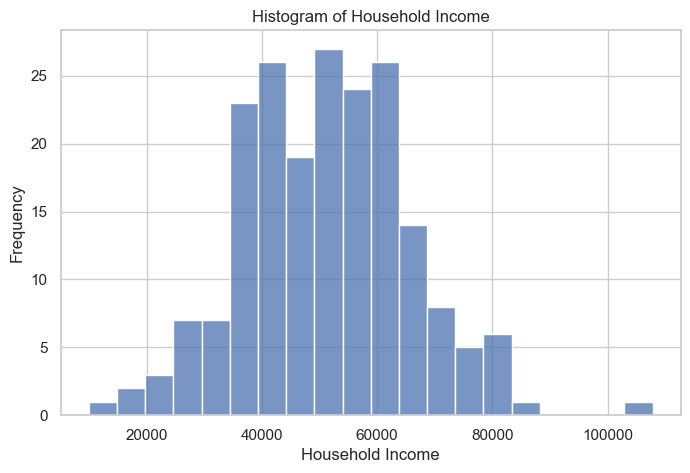

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df['Household_Income'], bins=20, kde=False)

plt.title("Histogram of Household Income")
plt.xlabel("Household Income")
plt.ylabel("Frequency")
plt.show()

## GAUSSIAN (NORMAL) DISTRIBUTION

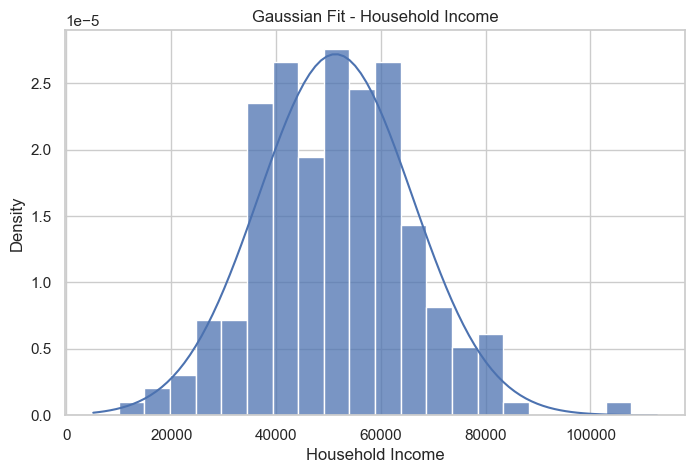

In [48]:
mean = df['Household_Income'].mean()
std = df['Household_Income'].std()

plt.figure(figsize=(8,5))

# Histogram with density
sns.histplot(df['Household_Income'], bins=20, stat='density')

# Generate values
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)

# Plot Gaussian curve
plt.plot(x, p)

plt.title("Gaussian Fit - Household Income")
plt.xlabel("Household Income")
plt.ylabel("Density")
plt.show()

## CALCULATE SKEWNESS AND KURTOSIS

-> How to Interpret Results
1. Skewness :-

≈ 0 → Normally distributed

> 0 → Right skewed (high income outliers)

< 0 → Left skewed

2. Kurtosis :-

≈ 0 → Normal peak

> 0 → More peaked (heavy tails)

< 0 → Flat distribution

In [49]:
income_skewness = skew(df['Household_Income'])
income_kurtosis = kurtosis(df['Household_Income'])

print("Skewness:", income_skewness)
print("Kurtosis:", income_kurtosis)

Skewness: 0.2544239323862924
Kurtosis: 0.5487858102999215


## Data Categorization

 ## Histogram and KDE (Kernel Density Estimation)

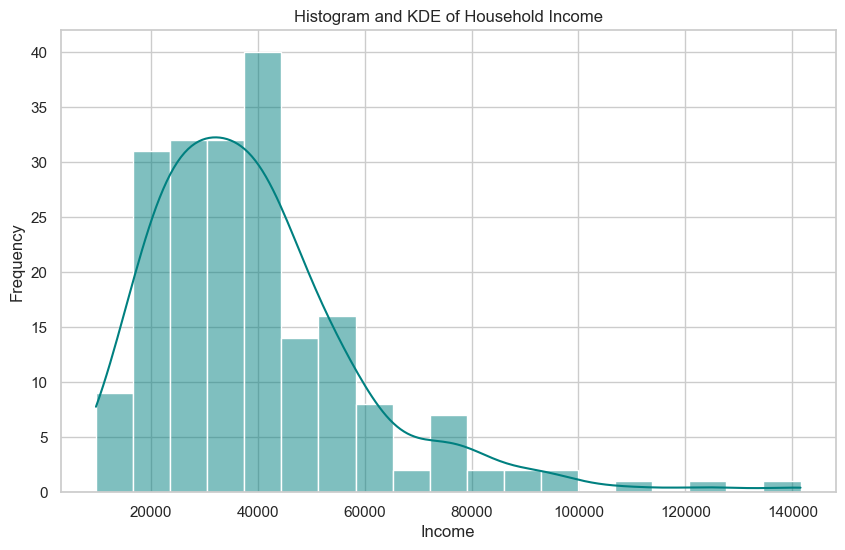

In [50]:
# --- STEP 1: Create Sample Data (Replace this with your actual df = pd.read_csv('file.csv')) ---
np.random.seed(42)
data_size = 200
df = pd.DataFrame({
    'Household_Income': np.random.lognormal(mean=10.5, sigma=0.5, size=data_size),
    'Age': np.random.randint(18, 80, size=data_size),
    'Family_Size': np.random.randint(1, 6, size=data_size),
    'Education_Level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], size=data_size),
    'Area': np.random.choice(['Urban', 'Rural'], size=data_size)
})

# Setting the visual style
sns.set_theme(style="whitegrid")

# --- STEP 2: Histogram and KDE (Kernel Density Estimation) ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Household_Income'], kde=True, color='teal')
plt.title('Histogram and KDE of Household Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


## BoxPlot Comparing Family Size by Education Level

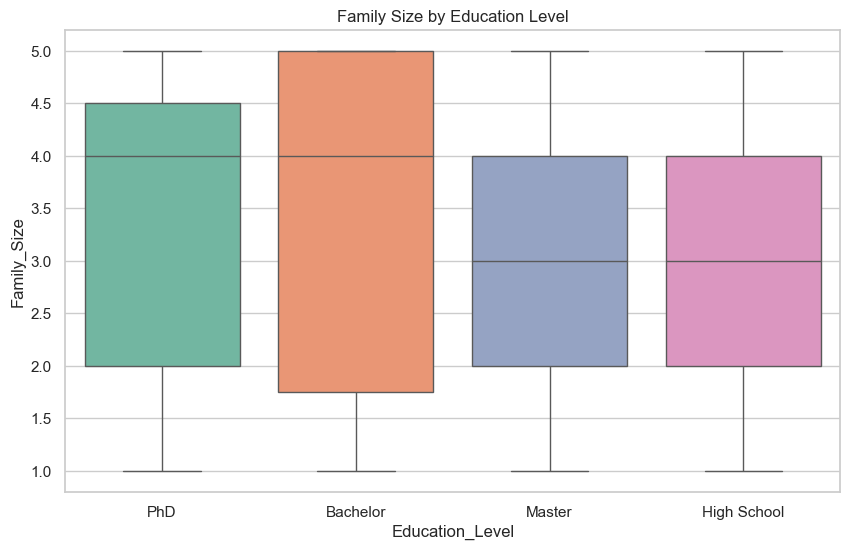

In [51]:
# --- STEP 3: Boxplot comparing Family Size by Education Level ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Education_Level', y='Family_Size', data=df, palette='Set2', hue='Education_Level', legend=False)
plt.title('Family Size by Education Level')
plt.show()

<Figure size 1000x800 with 0 Axes>

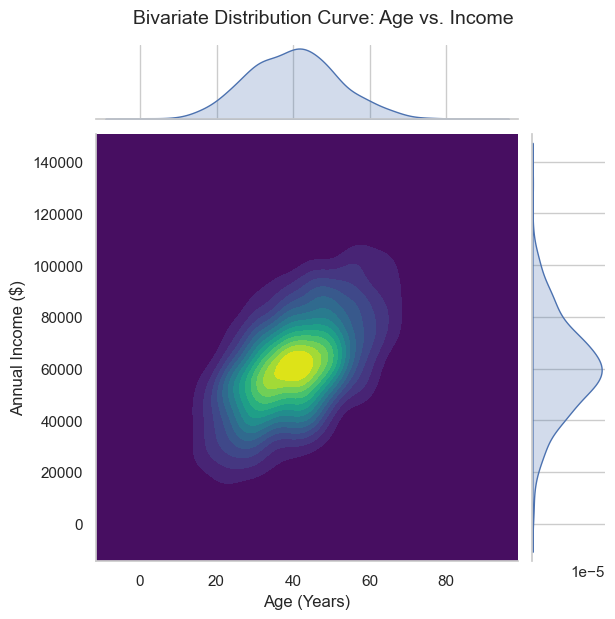

In [56]:
import warnings

# Suppress all FutureWarnings to ensure a clean output
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- STEP 1: Generate Sample Data ---
# (Replace this section with your actual data loading: df = pd.read_csv('file.csv'))
np.random.seed(42)
n = 500
age = np.random.normal(40, 12, n)
# Create income with a slight correlation to age
income = 20000 + (age * 1000) + np.random.normal(0, 15000, n)

df = pd.DataFrame({'Age': age, 'Income': income})

# --- STEP 2: Create a Professional Bivariate Distribution Curve ---
# Using a JointPlot with KDE (Kernel Density Estimation) is the best way 
# to show the "Distribution Curve" for two variables simultaneously.

plt.figure(figsize=(10, 8))

# We use jointplot to see the individual (marginal) curves and the combined (joint) curve
g = sns.jointplot(
    data=df, 
    x="Age", 
    y="Income", 
    kind="kde",      # This creates the smooth "distribution curves"
    fill=True,       # Fills the contours for a professional look
    cmap="viridis",  # Using a standard, modern color map
    thresh=0,        # Ensures the curve extends to the edges
    levels=15        # Adds detail to the density layers
)

# Adding titles and adjusting layout
g.fig.suptitle('Bivariate Distribution Curve: Age vs. Income', y=1.03, fontsize=14)
g.set_axis_labels('Age (Years)', 'Annual Income ($)', fontsize=12)

plt.show()